In [1]:
# all packages and helper functions (not directly answering the main question) can be found in helper_functions_1_2_3.py and ploting_functions:
from helper_functions_1_2_3 import *
from ploting_functions import *

# 1.1

1424219 hits, estimate of pi = 3.404730030169302


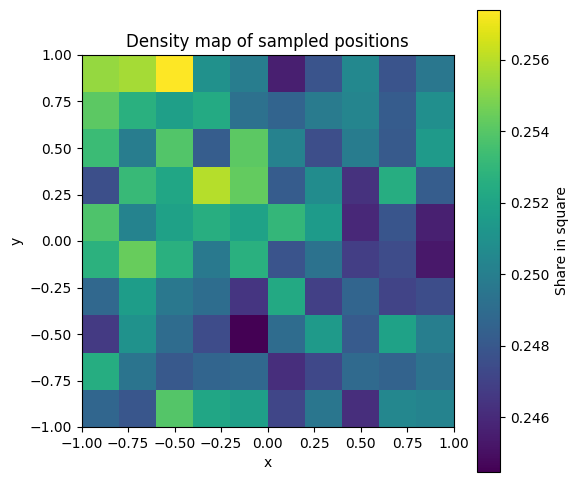

In [10]:
# 3.1
trials = 2_000_000

@nb.njit
def exercise_1_1(trials, delta=0.4, x_start =-1.0, y_start=-1.0):
    # step 0. settings for simulation and initialise holders
    position = np.array([x_start, y_start]) # Default is to start in the bottom left corner 
    N = trials
    number_hits = 0
    succesful_throws = 0
    x_pos_list = np.empty(N)
    y_pos_list = np.empty(N)

    # step 1. Do the simulation. As there is dependence over time, we cannot not use parallelization to speed up the proces
    for i in range(N):
        peb_loc = circle_throw(delta) + position # new peb location = throw plus current location 
        # Check if in square 
        if is_in_square(peb_loc):
            # 1. Update the position
            position = peb_loc
            # 2. Update the trial counter 
            succesful_throws +=1
            if is_in_circle(position):
                number_hits += 1

        x_pos_list[i] = position[0]
        y_pos_list[i] = position[1]
    pi_est = 4*number_hits/succesful_throws ### 
    rejection = 0 # I only do this because numba syntax requirement

    return number_hits, pi_est, x_pos_list, y_pos_list, rejection

hits_11, pi_est_11, x_positions_11, y_positions_11, _ = exercise_1_1(trials)
print(hits_11 , "hits, estimate of pi =", pi_est_11 )
hist_heat_map(x_positions_11, y_positions_11)

The MC estimate of pi is: 3.406
With a 95 pct. Confidence interval of MC estimate of pi: [3.403 3.409]


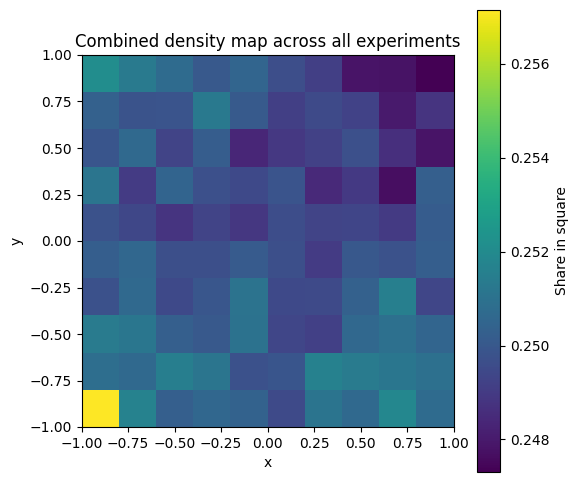

In [ ]:
# We can also do the experiement 1_000 times with 20_000 trials in each experiment to get the confidence interval
def dist_ex_1_K_times(nr_exp = 1000, trials= 20_000, exc= exercise_1_1):
    pi_est_list = []
    nr_exp = 1000
    pos = np.empty((nr_exp,2, trials))
    for j in nb.prange(nr_exp): # we can do this because of parallelization
        _, pi_est_11, x_positions_11, y_positions_11, _ = exc(trials)
        pi_est_list.append(pi_est_11)
        pos[j,0,:] = x_positions_11
        pos[j,1,:] = y_positions_11
    MC_est = np.mean(pi_est_list)
    std_ = np.std(pi_est_list, ddof=1)
    return pi_est_list, pos, MC_est, std_
    
pi_est_list, pos, MC_est, std_ = dist_ex_1_K_times(nr_exp = 1000, trials= 20_000, exc= exercise_1_1)
print(f'The MC estimate of pi is: {round(MC_est,3)}\nWith a 95 pct. Confidence interval of MC estimate of pi: {np.round(MC_est + 3.64 * np.array([-1, 1]) * std_/np.sqrt(1000),3)}')
hist_heat_map_all(pos, number_of_bins=10)

# Discussion of 1.1
The estimator of $\hat{\pi}=4\frac{\text{accepted positions inside circle}}{\text{accepted positions inside square}}$, which means we ignore rejected throws. This will be an unbiased estimator of $\pi$ if the throws are uniformly distributed over the square. When we run the experiment once with $2_000_000$ trials, our estimate for $\pi$ is around 10% higher than the true value of $\pi$. As this estimate depends on randomness, we perform the experiement 1_000 times with $20_000$ trials to get an MC estimate of the experiements estimate of $\pi$. We now get am MC estimate of $\pi=3.405$ with a 95 pct. confidence interval of [3.404 3.407], which does not include the true value of $\pi$. 

The biased estimate of $\pi$ arises from our sampling method. In our experiment, the sample within each experiement is not iid. The pebble throws are neither identical nor independent of one another. In this experiement, we sample based on the path taken by the student throwing pebbles, as opposed to an iid distribution of throws. As we only record successful throws into the square, corner positions have a success rate of 25%, and from border positions, there is a 50% chance of a throw being valid. Hence, the majority of throws from these regions are unsuccessful and are not recorded. Pebble throws are also not treated identically. The pebble throws are not independent as current position for the pebble throw depends on the previous positino plus the previous pebble throw. If $\delta$ is relatively low, it can hard to escape an area of the square within a finite number throws. 

As $\delta$ is relatively high and set the number of throws to $20_000$, this is not the real problem. The problem is that pebble throws are not identical. In the center of the circle, then all pebble throws will be accepted and will be uniformly distributed for the disk with $\delta$ as the radius. However, at the edge, the disk around the child will be truncated, where only 50% of throws will be accepted. The accepted moves are thus more likely to point inward towards the center, which creates a directional bias. The directional bias towads the center creates an upwards sample bias. 

From the histogram, the density is not uniform across the square. We observe a lower density near the boundaries, except for around $(-1,-1)$, and a slightly higher density in the central region. We notice some areas of higher density along the border but this is more than likely noise as opposed to any pattern. This supports the above above argument that coordinates along the borders of the square are under represented relative to inside the circle. It is also worth noting that we chose the number of trials to be 2_000_000 in order to lower the variance of the results and generate clearer patterns in the histogram, as smaller sample sizes are dominated by noise.

# 1.2

1569134 hits, estimate of pi = 3.138268


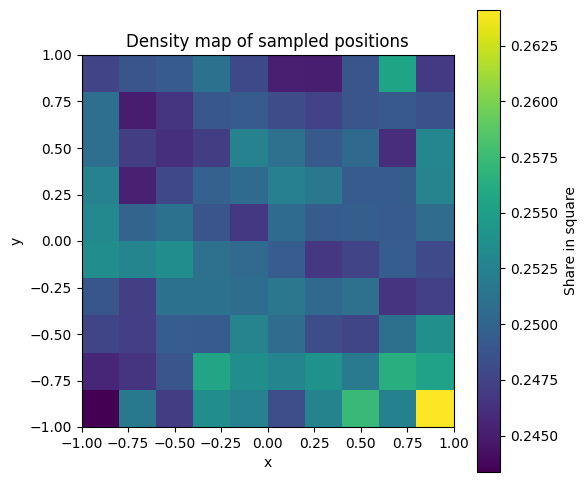

In [14]:
@nb.njit
def exercise_1_2(trials, delta = 0.4):
    position = np.array([-1.0,-1.0])
    N = trials
    number_hits = 0
    rejection = 0
    x_pos_list = []
    y_pos_list = []
    for _ in range(N):
        # find pebble location
        peb_loc = circle_throw(delta) + position
        if is_in_square(peb_loc):
            position = peb_loc
        else:
            rejection+=1

        # check if in circle. If the peb_loc was out, we place the peb at the previous location (do not update locatoin) and check if in circle
        if is_in_circle(position):
            number_hits += 1          

        # Save for mapping
        x_pos_list.append(position[0])
        y_pos_list.append(position[1])
    pi_est = 4 * number_hits / trials
    return number_hits, pi_est, x_pos_list, y_pos_list, rejection
    
hits_12, pi_est_12, x_positions_12, y_positions_12, rejection_12= exercise_1_2(trials)
print(hits_12 , "hits, estimate of pi =", pi_est_12 )
hist_heat_map(x_positions_12, y_positions_12)

The MC estimate of pi with method 2 is: 3.13936
With a 95 pct. Confidence interval of MC estimate of pi: [3.13563 3.14309]


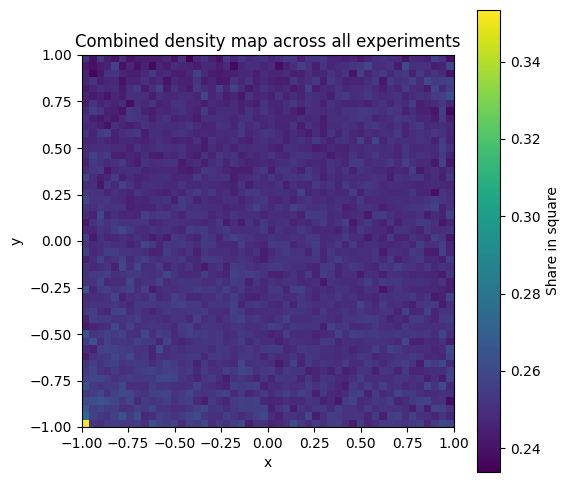

In [15]:
pi_est_list_2, pos_2, MC_est_2, std_2 = dist_ex_1_K_times(nr_exp = 1000, trials= 20000, exc= exercise_1_2)
print(f'The MC estimate of pi with method 2 is: {round(MC_est_2,5)}\nWith a 95 pct. Confidence interval of MC estimate of pi: {np.round(MC_est_2 + 3.64 * np.array([-1, 1]) * std_2/np.sqrt(1000),5)}')
hist_heat_map_all(pos_2, number_of_bins=50)

The estimator of $\hat{\pi}=4\frac{\text{accepted new position or previous position}}{\text{Throws}}$. Following the second setup of the game, we see our estimate for $\pi$ is much more accurate than before. When we do the MC estimate, we get an estimate of $\pi=3.142$. with a 95. pct. confidence interval of $[3.138, 3.146]$, which includes the true value of $\pi$. 

The reason why this estimator is better is because it does not have the inwards bias, which created an upwards directed bias. In excercise 1.1, the truncated disk created a bias as we only accepted throws on the disk within the square. It therefore did not explore the space of the disk uniformly. In the present setup, rejected throws are counted by recording the current position again. This removes the previous inward bias in the accepted samples, because boundary and corner positions are no longer underrepresented.

The precise estimate of $\pi$ indicates that the histogram should show relatively uniform distribution, as there is a notable higher sampling density along the borders of the square, specifically along the left and top. We see from increased lighter regions, we were previously discarding many observations along the border as the pebble was being thrown out of the area. The uniform placement of pebbles is even clearer for the histogram over the 1000 experiments.

# 1.3 and 1.4

In [6]:
# 1.3 and 1.4
delta_range = np.arange(0,3+ 0.000001, 0.01) # around 300 
T = 100
trials_list = [100, 1000, 2000, 10000]
trials = 2000
delta_sim = {}
delta_sim_var = {}
delta_sim_rejection = {}
delta_arr = np.zeros((len(delta_range), len(trials_list),3))

@nb.njit(parallel=True)
def i_loop(delta_temp, trials=2000):
    sim_1_3 = np.empty(T)
    sim_1_4 = np.empty(T)
    for i in nb.prange(T): # It tries to do all of these at the same time -> reducing time cost by factor T (if allowed to parralise all at the same time)
        _, pi_est, _, _,rejection = exercise_1_2(trials, delta = delta_temp)
        sim_1_3[i] = pi_est
        sim_1_4[i] = float(rejection/trials)
    return sim_1_3, sim_1_4

for trials_idx in range(len(trials_list)):
    trials_loop = trials_list[trials_idx]
    for idx in nb.prange(len(delta_range)):
        delta_temp = delta_range[idx]
        delta_sim[delta_temp], delta_sim_rejection[delta_temp] = i_loop(delta_temp, trials_loop)
        delta_arr[idx, trials_idx,:] = delta_temp, np.mean((delta_sim[delta_temp]-np.pi)**2), np.mean(delta_sim_rejection[delta_temp])
        if trials_loop ==2000 and delta_temp in [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0, 2.0, 3.0]:
            idx = int(round(delta_temp / 0.01))
            print("delta=",delta_temp ,"MSD=", delta_arr[idx, trials_idx, 1])

        

delta= 0.0 MSD= 9.869604401089358
delta= 0.1 MSD= 0.1234806626779272
delta= 0.2 MSD= 0.04525333969347471
delta= 0.4 MSD= 0.009149644922954706
delta= 0.5 MSD= 0.00838573647958011
delta= 0.6 MSD= 0.007017608566176975
delta= 0.8 MSD= 0.005325160205712255
delta= 1.0 MSD= 0.005825198235314268
delta= 2.0 MSD= 0.007005722116144573
delta= 3.0 MSD= 0.016395041239755315


Starting with $\delta = 0$, we have our highest value for the MSD. This is because there is no exploration and the child stays at $(-1,-1)$. This gives $\hat{\pi_{\delta=0}}=0$, which gives $\mathbb{E}\left[\pi^2\right]=9.86$. As $\delta$ increases, exploration around the square increases as the child can travel further. As delta continues to increase up to 0.8, we see the MSD fall to a minimum value. As delta increases past this point, MSD fluctuates between 0.005 and 0.02, climbing slowly. This is as while we have exploration, most throws will land outside the square, thus we have slightly less freedom in the regions that we will visit.

In [7]:
def plot_1_5(delta_arr):
    '''Plot question 1.5'''
    plt.figure(figsize=(7,5))

    for i in range(delta_arr.shape[1]):
        plt.plot(
            delta_arr[:,i,0],
            delta_arr[:,i,1],
            linewidth=2,
            markersize=6,
            label =f'Trials: {trials_list[i]}'
        )

    plt.xlabel("Delta")
    plt.ylabel("Mean squared deviation of estimate of π")
    plt.title("Effect of Delta on π Estimate")
    plt.legend()

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,5))

    for i in range(delta_arr.shape[1]):
        plt.plot(
            delta_arr[:,i,0],
            delta_arr[:,i,2],
            linewidth=2,
            markersize=6,
            label =f'Trials: {trials_list[i]}'
        )

    plt.xlabel("Delta")
    plt.ylabel("Rejection rate")
    plt.title("Rejection Rate")
    plt.legend()

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

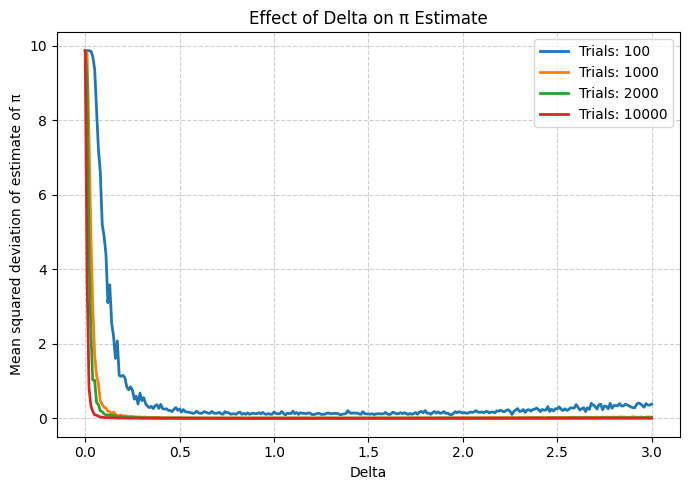

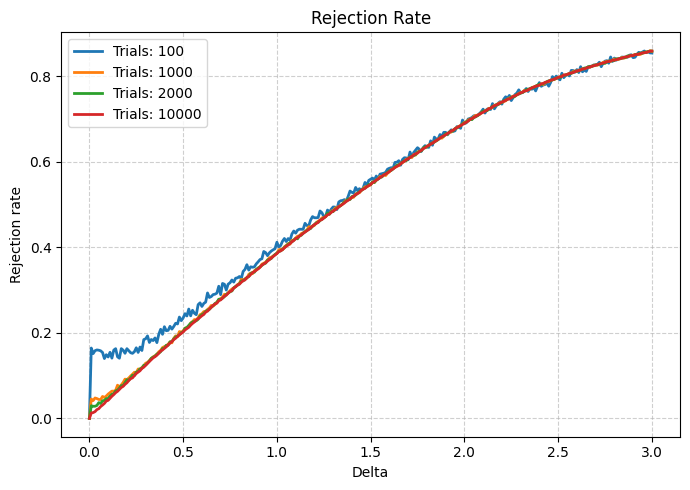

In [8]:
# 1.5
plot_1_5(delta_arr)

The MSD continues to fall as $\delta$ increases and eventually levels off at delta = 0.4, where it remains relatively flat between values of 0.005 and 0.02, as delta increases to 3. As the number of trials within each experiement increases, it reduces the variance, which results in a lower MSD for all deltas. Higher trials also lowers the variance betweeen experiments, which makes the above graphs smoother. Consequently, as both trials and delta increase, we generally see a lower MSD. The rejection rate increases with delta and reaches it maximum of of 86% at our boundary of $\delta=3$. This result is expected, as for large deltas relative to the size of the square, the chance that the pebble is thrown outside is higher, and thus we see more rejections.